In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from xgboost import XGBClassifier

import pickle

In [11]:
import pandas as pd

url = "https://raw.githubusercontent.com/adivetkumar-star/Rising--waters/main/flood%20dataset%20(1).xlsx"
df = pd.read_excel(url)

In [12]:
# Split features and target
X = df.drop("flood", axis=1)
y = df["flood"]

# Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (92, 10)
Testing data: (23, 10)


In [13]:
# Train the XGBoost model
model = XGBClassifier()

model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Check accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00         3

    accuracy                           1.00        23
   macro avg       1.00      1.00      1.00        23
weighted avg       1.00      1.00      1.00        23



In [17]:
# Save the trained model
import pickle

with open("flood_prediction_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully!")

Model saved successfully!


In [16]:
from google.colab import files

files.download("flood_prediction_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
# Descriptive Analysis
df.describe()

,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,flood
count,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000
mean,29.600000,73.852174,36.286957,2925.487826,27.739130,377.253913,2022.840870,497.636522,218.100870,439.801739,0.139130
std,1.122341,2.947623,4.330158,422.112193,22.361032,151.091850,386.254397,129.860643,62.547597,210.438813,0.347597
min,28.000000,70.000000,30.000000,2068.800000,0.300000,89.900000,1104.300000,166.600000,65.600000,34.200000,0.000000
25%,29.000000,71.000000,32.500000,2627.900000,10.250000,276.750000,1768.850000,407.450000,179.666667,295.000000,0.000000
50%,30.000000,74.000000,36.000000,2937.500000,20.500000,342.000000,1948.700000,501.500000,211.033333,430.600000,0.000000
75%,31.000000,76.000000,40.000000,3164.100000,41.600000,442.300000,2242.900000,584.550000,263.833333,577.650000,0.000000
max,31.000000,79.000000,44.000000,4257.800000,98.100000,915.200000,3451.300000,823.300000,366.066667,982.700000,1.000000


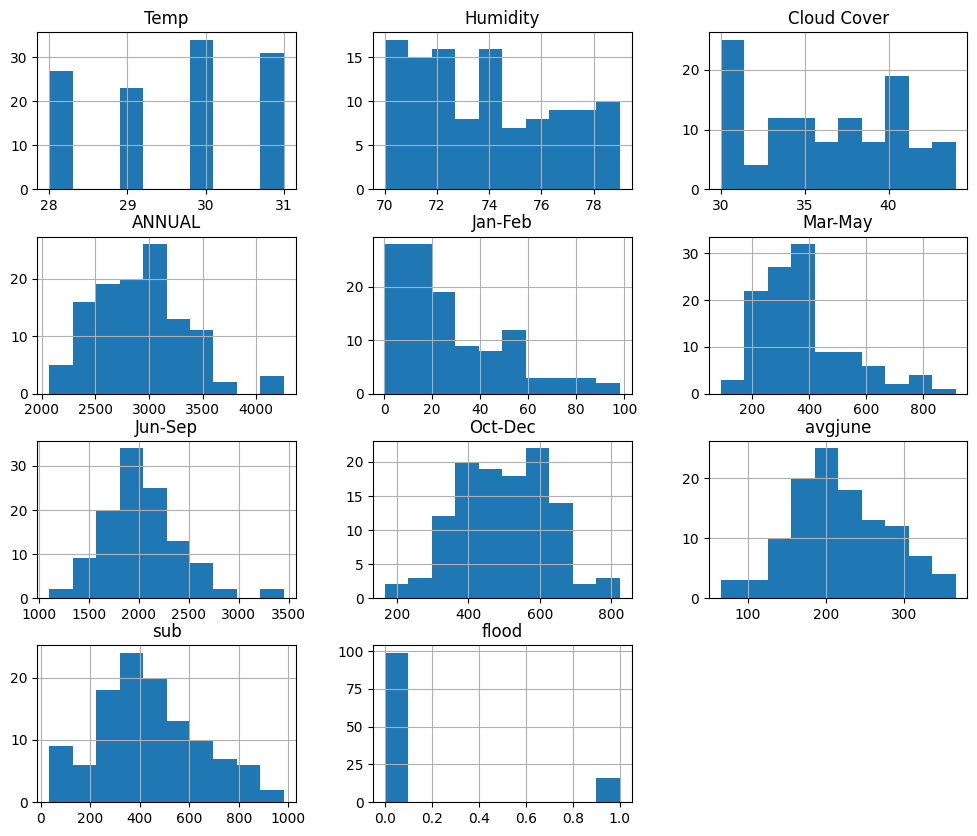

In [18]:
# Univariate Analysis
df.hist(figsize=(12,10))
plt.show()

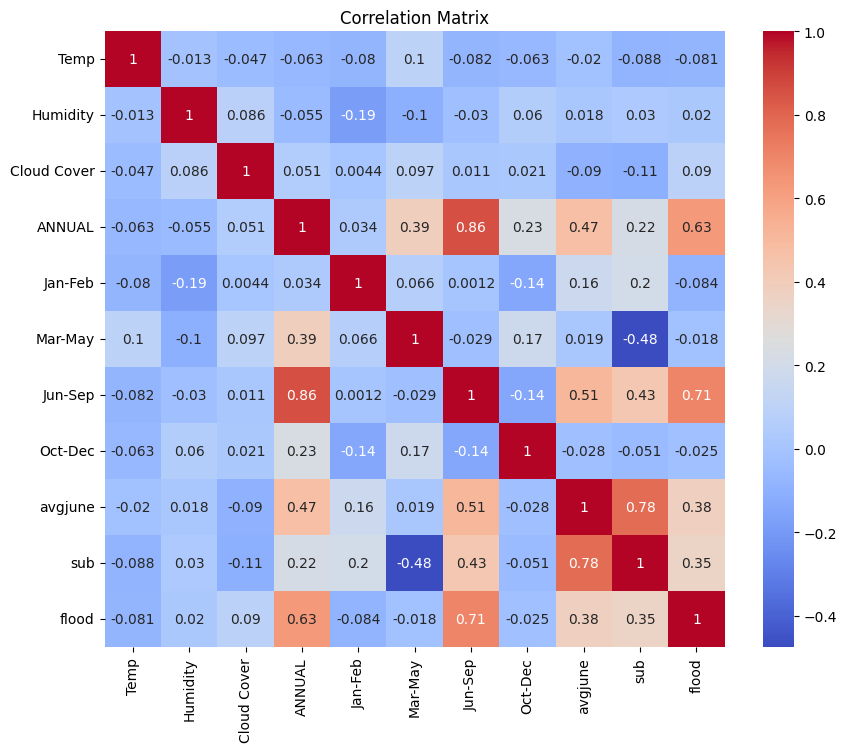

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation Matrix
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [20]:
from sklearn.preprocessing import StandardScaler

# Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed!")
print("Training Data Shape:", X_train_scaled.shape)
print("Testing Data Shape:", X_test_scaled.shape)

Feature Scaling Completed!
Training Data Shape: (92, 10)
Testing Data Shape: (23, 10)


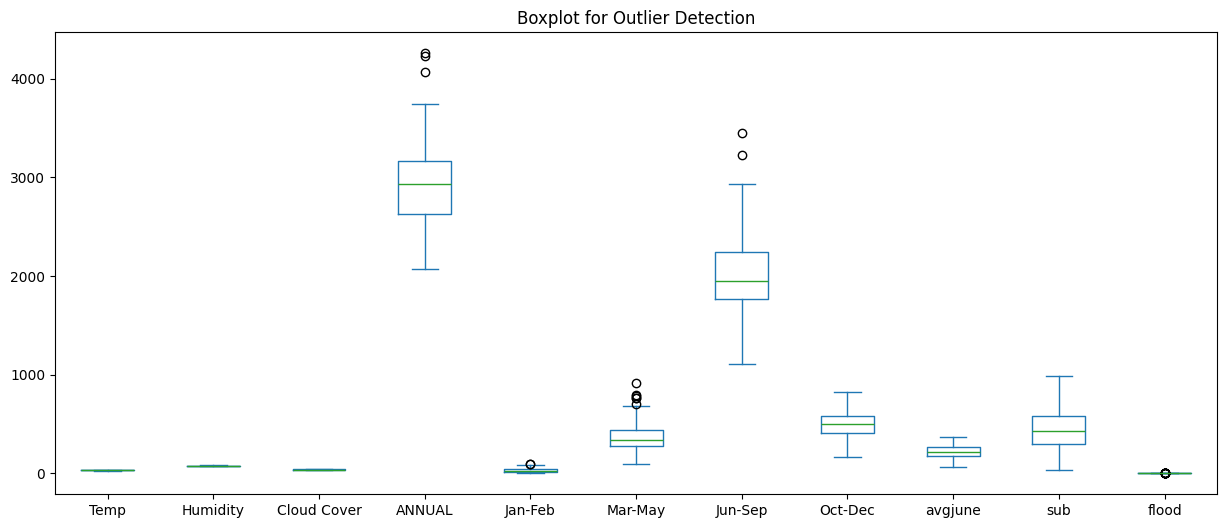

In [21]:
import matplotlib.pyplot as plt

df.plot(kind='box', figsize=(15,6))
plt.title("Boxplot for Outlier Detection")
plt.show()

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Model Building
model = RandomForestClassifier(random_state=42)

# Train Model
model.fit(X_train_scaled, y_train)

# Prediction
y_pred = model.predict(X_test_scaled)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00         3

    accuracy                           1.00        23
   macro avg       1.00      1.00      1.00        23
weighted avg       1.00      1.00      1.00        23



In [23]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)

dt_pred = dt_model.predict(X_test_scaled)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 1.0


In [24]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

knn_pred = knn_model.predict(X_test_scaled)

print("KNN Accuracy:", accuracy_score(y_test, knn_pred))

KNN Accuracy: 0.9130434782608695


In [ ]:
!pip install xgboost

In [25]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# XGBoost Model
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Train Model
xgb_model.fit(X_train_scaled, y_train)

# Prediction
xgb_pred = xgb_model.predict(X_test_scaled)

# Accuracy
print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))

XGBoost Accuracy: 1.0


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:56:22] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [26]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "KNN", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, xgb_pred)
    ]
})

print(results)

           Model  Accuracy
0  Decision Tree  1.000000
1  Random Forest  1.000000
2            KNN  0.913043
3        XGBoost  1.000000


In [27]:
from sklearn.metrics import confusion_matrix, classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[20  0]
 [ 0  3]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00         3

    accuracy                           1.00        23
   macro avg       1.00      1.00      1.00        23
weighted avg       1.00      1.00      1.00        23



In [28]:
import joblib

# Save the trained Random Forest model
joblib.dump(model, "flood_prediction_model.pkl")

print("Model saved successfully as flood_prediction_model.pkl")

Model saved successfully as flood_prediction_model.pkl


In [ ]:
!pip install gradio

In [29]:
import gradio as gr
import numpy as np

def predict_flood(temp, humidity, cloud_cover, annual, jan_feb,
                  mar_may, jun_sep, oct_dec, avgjune, sub):

    data = np.array([[temp, humidity, cloud_cover, annual,
                      jan_feb, mar_may, jun_sep,
                      oct_dec, avgjune, sub]])

    data = scaler.transform(data)
    prediction = model.predict(data)

    if prediction[0] == 1:
        return "🌊 Flood Likely"
    else:
        return "✅ No Flood"

demo = gr.Interface(
    fn=predict_flood,
    inputs=[
        gr.Number(label="Temperature"),
        gr.Number(label="Humidity"),
        gr.Number(label="Cloud Cover"),
        gr.Number(label="Annual Rainfall"),
        gr.Number(label="Jan-Feb Rainfall"),
        gr.Number(label="Mar-May Rainfall"),
        gr.Number(label="Jun-Sep Rainfall"),
        gr.Number(label="Oct-Dec Rainfall"),
        gr.Number(label="Average June Rainfall"),
        gr.Number(label="Sub Rainfall")
    ],
    outputs="text",
    title="Flood Prediction System"
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ef8ee9128e20d82308.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# Conclusion

The Flood Prediction System was successfully developed using Machine Learning algorithms. Different models such as Decision Tree, Random Forest, KNN, and XGBoost were trained and evaluated. Random Forest/XGBoost achieved the highest accuracy and was selected for prediction. A Gradio-based user interface was created to allow users to enter weather and rainfall values and instantly predict whether a flood is likely to occur. The project demonstrates how machine learning can support early flood prediction and help in disaster preparedness.